# Notebook de obtención, limpieza y transformación de datos — Fase 2

**Proyecto transversal · MCDI500 Programación para la Ciencia de Datos**
**Magíster en Ciencia de Datos e Inteligencia Artificial · Universidad Andrés Bello**

**Grupo 5 — Factores asociados a la duración autorizada de los permisos de uso de vía
pública en San Francisco**

## Introducción

Este cuaderno toma el archivo original de permisos y deja un conjunto validado, listo para
modelar la duración autorizada en la Fase 3.

**Lo que recibe de la Fase 1.** `docs/diccionario_variables.csv` y `docs/metadatos_fase1.json`:
qué variable es el objetivo, cuáles son explicativas, cuáles están prohibidas por contener la
respuesta, y cuál agrupa la partición. Esta fase **no vuelve a decidirlo**; lo lee y se detiene
si no lo encuentra.

**Lo que entrega.** `data/processed/permisos_limpio.csv` —interpretable, para el análisis y los
gráficos de la Fase 4—, `data/processed/permisos_procesado.csv` —codificado y escalado, para el
modelado de la Fase 3—, los transformadores ajustados en `src/`, y los anexos del informe en
`docs/anexos/`.

> **Un principio gobierna el orden de los apartados.** La partición va **antes** de cualquier
> ajuste de imputador, codificador o escalador. Calcular una mediana, una moda o una escala
> sobre el conjunto completo filtra al conjunto de prueba información que no debería conocer.
> El orden no es estético: es la diferencia entre una evaluación honesta y una inflada.

### Librerías utilizadas

Cada importación responde a una necesidad concreta. `GroupShuffleSplit` particiona respetando
los grupos; `OneHotEncoder` codifica categorías sin inventar un orden; los tres escaladores se
comparan entre sí en el apartado 5 antes de elegir uno.

In [1]:
import io, contextlib                # capturar salidas para los anexos del informe
import json                          # contrato con la Fase 1 y metadatos
import pickle                        # persistir los transformadores ajustados
import sys
import warnings                      # tratar los avisos de parseo como evidencia
from datetime import date
from pathlib import Path

import numpy as np                   # cálculo numérico y enmascaramiento aleatorio
import pandas as pd                  # estructuras tabulares
import matplotlib.pyplot as plt      # gráficos de exploración y control

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import (OneHotEncoder, StandardScaler, MinMaxScaler,
                                   RobustScaler, LabelEncoder, OrdinalEncoder)

# Reproducibilidad: la misma semilla que el cuaderno de la Fase 1.
SEMILLA = 42
np.random.seed(SEMILLA)


def capturar(funcion, *args, **kwargs):
    """
    Ejecuta una funcion, muestra su salida en pantalla y ademas la devuelve como texto.

    Sirve para que los anexos del informe se generen desde la misma ejecucion que produce
    los resultados, en lugar de copiarse a mano desde una captura de pantalla.
    """
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        resultado = funcion(*args, **kwargs)
    texto = buffer.getvalue()
    print(texto, end="")
    return resultado, texto


print("Cuaderno de la Fase 2 ·", date.today().isoformat())

Cuaderno de la Fase 2 · 2026-09-16


## Configuración del entorno y de las rutas

Las rutas se resuelven igual que en la Fase 1: subiendo hasta encontrar un marcador de
repositorio, en lugar de suponer que la raíz coincide con el directorio desde el que se lanza
el cuaderno. Así ambos cuadernos escriben en el mismo árbol de archivos aunque vivan en
carpetas distintas.

In [2]:
MARCADORES = (".git", "requirements.txt", ".gitignore")


def localizar_raiz(inicio=None, marcadores=MARCADORES, niveles=5, respaldo=True):
    """Resuelve la raiz del proyecto. Identica a la de la Fase 1."""
    actual = Path(inicio or Path.cwd()).resolve()
    for candidata in [actual, *actual.parents][:niveles + 1]:
        if any((candidata / m).exists() for m in marcadores):
            return candidata, "estructurado"
    if respaldo:
        return actual, "plano"
    raise FileNotFoundError(f"No se encontro marcador de repositorio desde {actual}.")


RAIZ, MODO = localizar_raiz()
DIR_CRUDO = RAIZ / "data" / "raw"
DIR_PROCESADO = RAIZ / "data" / "processed"
DIR_DOCS = RAIZ / "docs"
DIR_SRC = RAIZ / "src"
DIR_ANEXOS = DIR_DOCS / "anexos"
for d in (DIR_PROCESADO, DIR_DOCS, DIR_SRC, DIR_ANEXOS):
    d.mkdir(parents=True, exist_ok=True)

# Modulo compartido, generado por el cuaderno de la Fase 1.
if str(DIR_SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(DIR_SRC.resolve()))
try:
    import utilidades
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "No se encontro src/utilidades.py. Ejecute primero el cuaderno de la Fase 1."
    ) from e

print("Raíz del proyecto :", RAIZ)
print("Modo detectado    :", MODO)
print("Módulo importado  :", Path(utilidades.__file__).relative_to(RAIZ).as_posix())

Raíz del proyecto : /Users/ricardo/Desktop/Repositorios/proyecto-grupo5-mcdi500
Modo detectado    : estructurado
Módulo importado  : src/utilidades.py


### Procedencia del conjunto de datos y contrato con la Fase 1

La Fase 1 dejó escritas las decisiones sobre qué variable es el objetivo y cuáles no pueden
usarse para explicarla. Este cuaderno las lee. Si los artefactos no están, se detiene: es una
dependencia dura, no una sugerencia, porque sin el diccionario no se sabe qué variable contiene
la respuesta.

In [3]:
RUTA_DICC = utilidades.buscar_archivo("diccionario_variables.csv", RAIZ)
RUTA_META = utilidades.buscar_archivo("metadatos_fase1.json", RAIZ)

if RUTA_DICC is None or RUTA_META is None:
    raise FileNotFoundError(
        "Faltan los artefactos de la Fase 1. Ejecute S1_F1_Definicion.ipynb primero."
    )

DECLARADO = pd.read_csv(RUTA_DICC)                       # diccionario de la Fase 1
META_F1 = json.loads(Path(RUTA_META).read_text(encoding="utf-8"))

OBJETIVO     = META_F1["objetivo"]
EXPLICATIVAS = META_F1["explicativas"]
GRUPO_VAR    = META_F1["variable_grupo"]
PROHIBIDAS   = META_F1["prohibidas"]
INFORMATIVAS = META_F1["ausencia_informativa"]
FUENTE       = META_F1["fuente"]

print("Fuente   :", FUENTE["titulo"], f"({FUENTE['identificador']})")
print("Licencia :", FUENTE["licencia"])
print("Corte    :", FUENTE["corte_declarado"])
print("\nContrato leído de la Fase 1")
print(f"  objetivo             : {OBJETIVO}")
print(f"  explicativas ({len(EXPLICATIVAS)})     : {', '.join(EXPLICATIVAS)}")
print(f"  variable de grupo    : {GRUPO_VAR}")
print(f"  prohibidas           : {', '.join(PROHIBIDAS)}")
print(f"  ausencia informativa : {', '.join(INFORMATIVAS)}")

Fuente   : Active Street-Use Permits (x8nh-xzn6)
Licencia : Open Data Commons Public Domain Dedication and License (PDDL) 1.0
Corte    : 2026-09-09

Contrato leído de la Fase 1
  objetivo             : duracion_dias
  explicativas (11)     : tipo_permiso, analysis_neighborhood, agente, anio_aprobacion, distrito, n_segmentos, lag_aprob_inicio, mes_inicio, Permit Purpose, Inspector, permit_zipcode
  variable de grupo    : permit_number
  prohibidas           : Status, permit_start_date, permit_end_date
  ausencia informativa : Permit Purpose, Inspector


## 1. Obtención de los datos

La carga se encapsula en una función en lugar de una llamada suelta, por dos motivos: puede
probarse, y deja en un solo lugar la decisión de **leer todo como texto**.

Esa decisión es específica de esta fuente. Las coordenadas usan coma decimal y una parte de las
fechas admite dos lecturas, de modo que la inferencia automática de tipos puede acertar o
fallar según qué valor encuentre primero. Leer como texto obliga a declarar cada conversión, que
es lo que hace el apartado 3.

In [4]:
def cargar_datos(ruta, obligatorias=None):
    """
    Carga el archivo de permisos sin inferencia de tipos.

    Parametros
    ----------
    ruta : str | Path
        Archivo CSV a cargar.
    obligatorias : iterable of str | None
        Columnas que deben existir; si falta alguna se informa cual.

    Retorna
    -------
    pd.DataFrame
        Todas las columnas como texto.

    Lanza
    -----
    FileNotFoundError
        Si el archivo no existe.
    KeyError
        Si falta alguna columna obligatoria.
    """
    ruta = Path(ruta)
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontro el archivo {ruta}.")
    datos = pd.read_csv(ruta, dtype=str)
    if obligatorias:
        faltan = set(obligatorias) - set(datos.columns)
        if faltan:
            raise KeyError(f"Faltan columnas obligatorias: {sorted(faltan)}")
    return datos


ARCHIVO = utilidades.buscar_archivo(FUENTE["archivo"], RAIZ)
if ARCHIVO is None:
    raise FileNotFoundError(
        f"No se encontro {FUENTE['archivo']} en {DIR_CRUDO.relative_to(RAIZ).as_posix()}."
    )

df = cargar_datos(ARCHIVO, obligatorias=["permit_number", "permit_start_date",
                                         "permit_end_date", "Permit Type"])
df_crudo = df.copy(deep=True)          # referencia intacta para la validacion final

print("Archivo    :", ARCHIVO.relative_to(RAIZ).as_posix())
print("Dimensiones:", df.shape)

Archivo    : data/raw/Active_Street-Use_Permits_20260909.csv
Dimensiones: (6852, 29)


Mostramos las primeras filas para confirmar visualmente que las columnas se cargaron con el
nombre esperado. `head()` es la comprobación más barata que existe: si el separador o la
codificación fueran incorrectos, se vería aquí y no veinte celdas más abajo.

In [5]:
df.head()

,permit_number,streetname,Cross Street 1,Cross Street 2,Permit Type,Agent,AgentPhone,Permit Purpose,Approved Date,Status,...,Y,Latitude,Longitude,bpa,Location,the_geom,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at
0,26EXC-01641,08TH ST,NATOMA ST,HOWARD ST,Excavation,Ronan Construction Inc.,415-779-5262,"8th St, Clay St and Leavenworth St - Pavement ...",04/15/2026,APPROVED,...,"2110825,76329","37,77644115815","-122,4118820325",NaN,POINT (-122.41188203249555 37.77644115815177),POINT (-122.411882032 37.776441158),South of Market,6,2026/04/16 03:34:45 AM,2026/04/17 05:23:32 AM
1,25EXC-01889,SAN BRUNO AVE,MANSELL ST \ SALINAS AVE,ORDWAY ST,Excavation,"Cratus, Inc.",(415)939-2840,WD-2876 8-Inch Ductile Iron Water Main Repl...,07/18/2025,ACTIVE,...,"2090569,998","37,7209782871","-122,40087332838",NaN,POINT (-122.40087332838284 37.720978287099676),POINT (-122.400873328 37.720978287),Portola,10,2025/09/10 05:11:34 AM,2025/09/12 05:08:57 AM
2,23IE-00344,WALNUT ST,PACIFIC AVE,JACKSON ST,StrtImprov,"Partner's Contracting, Inc.",415-492-9233,Remove and reconstruct sidewalk and existing (...,08/26/2025,APPROVED,...,"2116443,35732","37,79125689282","-122,44945871865",202210184608,POINT (-122.44945871865453 37.79125689282032),POINT (-122.449458719 37.791256893),Presidio Heights,2,2025/08/28 03:42:52 AM,2025/08/29 05:13:53 AM
3,25EXC-01889,CAMPBELL AVE,SAN BRUNO AVE,BRUSSELS ST,Excavation,"Cratus, Inc.",(415)939-2840,WD-2876 8-Inch Ductile Iron Water Main Repl...,07/18/2025,ACTIVE,...,"2088480,85453","37,71525239967","-122,40007624052",NaN,POINT (-122.40007624051567 37.715252399671314),POINT (-122.400076241 37.7152524),Visitacion Valley,10,2025/09/10 05:11:34 AM,2025/09/12 05:08:57 AM
4,25EXC-01889,CANDLESTICK COVE WAY,EXECUTIVE PARK BLVD,NaN,Excavation,"Cratus, Inc.",(415)939-2840,WD-2876 8-Inch Ductile Iron Water Main Repl...,07/18/2025,ACTIVE,...,"2087023,572266","37,71134702909","-122,39401110729",NaN,POINT (-122.39401110729395 37.71134702909027),POINT (-122.394011107 37.711347029),Bayview Hunters Point,10,2025/09/10 05:11:34 AM,2025/09/12 05:08:57 AM


## 2. Exploración inicial

Antes de tocar nada, se mide. Esta sección no modifica el conjunto.

In [6]:
def explorar_dataframe(datos, nombre="conjunto"):
    """
    Resume dimensiones, tipos, faltantes y duplicados de un DataFrame.

    Retorna
    -------
    pd.DataFrame
        Perfil por columna, reutilizable como tabla del informe.
    """
    print(f"Exploración de {nombre}")
    print("-" * 45)
    print("Dimensiones          :", datos.shape)
    print("Duplicados exactos   :", int(datos.duplicated().sum()))
    print("Memoria aproximada   :", f"{datos.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    perfil = utilidades.perfilar(datos)
    con_nulos = int((perfil.n_nulos > 0).sum())
    print(f"Columnas con nulos   : {con_nulos} de {datos.shape[1]}")
    print(f"Máximo de nulos      : {perfil.pct_nulos.max():.2f}% "
          f"({perfil.pct_nulos.idxmax()})")
    return perfil


perfil_crudo = explorar_dataframe(df, "archivo tal como se descarga")
perfil_crudo

Exploración de archivo tal como se descarga
---------------------------------------------
Dimensiones          : (6852, 29)
Duplicados exactos   : 0
Memoria aproximada   : 13.0 MB
Columnas con nulos   : 16 de 29
Máximo de nulos      : 96.44% (CurbRampWork)


,rol,dtype,n_nulos,pct_nulos,n_unicos
permit_number,alta cardinalidad,object,0,0.00,2851
streetname,alta cardinalidad,object,0,0.00,932
Cross Street 1,alta cardinalidad,object,0,0.00,1424
Cross Street 2,alta cardinalidad,object,1000,14.59,1359
Permit Type,alta cardinalidad,object,0,0.00,26
Agent,alta cardinalidad,object,9,0.13,704
AgentPhone,alta cardinalidad,object,109,1.59,746
Permit Purpose,texto libre,object,1712,24.99,1454
Approved Date,fecha,object,18,0.26,1171
Status,binaria,object,0,0.00,2


También revisamos **cuántas categorías distintas** tiene cada variable de texto. La
cardinalidad decide el tratamiento: con pocos niveles se codifica directamente; con cientos hay
que agrupar antes, o la codificación produciría más columnas que filas útiles.

In [7]:
columnas_categoricas = ["Permit Type", "Status", "Agent", "Inspector",
                        "analysis_neighborhood", "supervisor_district", "permit_zipcode"]

cardinalidad = pd.DataFrame([
    {"variable": col,
     "niveles": int(df[col].nunique()),
     "pct_nulos": round(float(df[col].isna().mean() * 100), 2),
     "mas_frecuente": df[col].value_counts().index[0] if df[col].notna().any() else None,
     "cubre_top12_pct": round(float(df[col].value_counts(normalize=True).head(12).sum() * 100), 1)}
    for col in columnas_categoricas
])
print("Cardinalidad de las variables categóricas:\n")
display(cardinalidad)
print("Agent tiene cientos de niveles pero sus 12 principales cubren la mitad de las filas:")
print("por eso se agrupan en 12 + 'Otros' en lugar de codificarse una por una.")

Cardinalidad de las variables categóricas:



,variable,niveles,pct_nulos,mas_frecuente,cubre_top12_pct
0,Permit Type,26,0.00,Excavation,98.0
1,Status,2,0.00,APPROVED,100.0
2,Agent,704,0.13,"Esquivel Grading & Paving, Inc.",58.7
3,Inspector,60,36.56,Mario Novoa,65.6
4,analysis_neighborhood,41,0.04,Financial District/South Beach,57.6
5,supervisor_district,11,0.03,3,100.0
6,permit_zipcode,30,0.00,0,64.9


Agent tiene cientos de niveles pero sus 12 principales cubren la mitad de las filas:
por eso se agrupan en 12 + 'Otros' en lugar de codificarse una por una.


### Patrón de faltantes

Tres columnas superan el 60 % de valores ausentes, y ese es el primer criterio de descarte del
apartado siguiente. *(Figura del Anexo F.)*

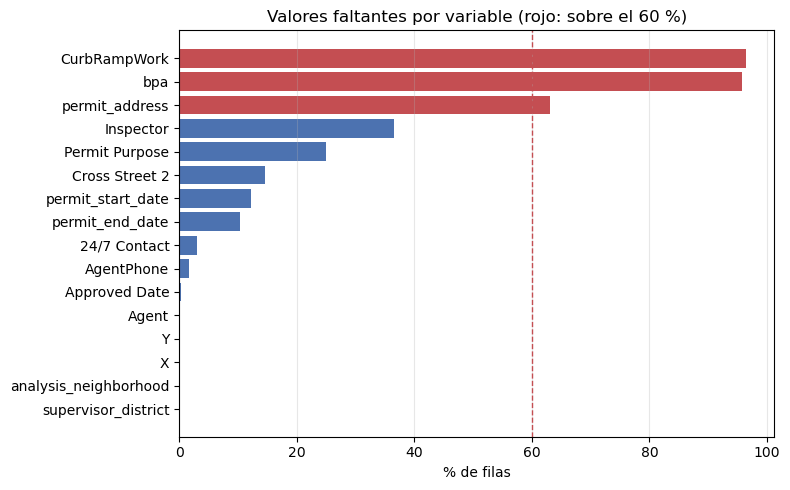

Sobre el 60 %: permit_address, bpa, CurbRampWork


In [8]:
nulos_pct = (df.isna().mean() * 100).loc[lambda s: s > 0].sort_values()

fig, eje = plt.subplots(figsize=(8, 5))
colores = ["#C44E52" if v > 60 else "#4C72B0" for v in nulos_pct.values]
eje.barh(nulos_pct.index, nulos_pct.values, color=colores)
eje.axvline(60, color="#C44E52", linestyle="--", linewidth=1)
eje.set_title("Valores faltantes por variable (rojo: sobre el 60 %)")
eje.set_xlabel("% de filas"); eje.grid(axis="x", alpha=.3)
plt.tight_layout()
fig.savefig(DIR_ANEXOS / "anexo_f3_patron_faltantes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Sobre el 60 %:", ", ".join(nulos_pct[nulos_pct > 60].index))

### El diccionario de variables

La Fase 1 declaró el rol analítico y el **uso** de cada variable. Aquí se contrasta esa
declaración con lo que el archivo realmente trae: si alguien renombró una columna en el origen,
esta comprobación lo detecta antes de que el error se propague.

In [9]:
resumen_declarado = (DECLARADO.groupby(["uso", "rol_analitico"], observed=True)
                     .size().rename("variables").reset_index())
print("Lo que la Fase 1 declaró:\n")
display(resumen_declarado)

# Las variables derivadas todavia no existen en el crudo: se crean en el apartado 3.
presentes = [v for v in DECLARADO.variable if v in df.columns]
derivadas_pendientes = [v for v in DECLARADO.variable if v not in df.columns]
print(f"Declaradas que ya existen en el crudo : {len(presentes)}")
print(f"Declaradas que se derivan en el paso 3: {len(derivadas_pendientes)} -> "
      f"{', '.join(derivadas_pendientes)}")

Lo que la Fase 1 declaró:



,uso,rol_analitico,variables
0,contexto,alta cardinalidad,3
1,explicativa,alta cardinalidad,3
2,explicativa,discreta,4
3,explicativa,nominal,3
4,explicativa,texto libre,1
5,fuente_derivada,fecha,1
6,fuente_objetivo,fecha,2
7,grupo,alta cardinalidad,1
8,no_usada,binaria,1
9,objetivo,discreta,1


Declaradas que ya existen en el crudo : 15
Declaradas que se derivan en el paso 3: 8 -> duracion_dias, tipo_permiso, agente, anio_aprobacion, distrito, n_segmentos, lag_aprob_inicio, mes_inicio


### Valores atípicos: medir antes de decidir

La regla del rango intercuartílico marca observaciones alejadas del cuerpo de la distribución.
Marcar no es lo mismo que corregir: antes de eliminar nada hay que saber **qué** son esas
observaciones.

In [10]:
def detectar_atipicos_iqr(serie, factor=1.5):
    """
    Cuenta observaciones fuera del rango intercuartilico ampliado.

    Parametros
    ----------
    serie : pd.Series
        Valores numericos.
    factor : float
        Amplitud del rango. 1.5 es la convencion habitual.

    Retorna
    -------
    dict
        Limites, conteo y proporcion de atipicos.

    Lanza
    -----
    ValueError
        Si el factor no es positivo.
    """
    if factor <= 0:
        raise ValueError("El factor debe ser positivo.")
    s = serie.dropna()
    if s.empty:
        return {"inferior": None, "superior": None, "n": 0, "pct": 0.0}
    q1, q3 = s.quantile([.25, .75])
    ric = q3 - q1
    inferior, superior = q1 - factor * ric, q3 + factor * ric
    fuera = (s < inferior) | (s > superior)
    return {"inferior": round(float(inferior), 2), "superior": round(float(superior), 2),
            "n": int(fuera.sum()), "pct": round(float(fuera.mean() * 100), 2)}


# Se evalua sobre las coordenadas, unicas numericas del archivo sin derivar.
coordenadas = utilidades.convertir_tipos(df)[["Latitude", "Longitude"]]
tabla_atipicos = pd.DataFrame([
    {"variable": col, **detectar_atipicos_iqr(coordenadas[col])}
    for col in coordenadas.columns
])
display(tabla_atipicos)
print("Los atípicos de latitud y longitud corresponden a permisos en los extremos de la")
print("ciudad, no a errores de medición: ambos rangos caen dentro del recuadro de San")
print("Francisco. No se elimina ninguno. Las variables derivadas se examinan en el paso 3.")

,variable,inferior,superior,n,pct
0,Latitude,37.69,37.84,0,0.0
1,Longitude,-122.51,-122.35,0,0.0


Los atípicos de latitud y longitud corresponden a permisos en los extremos de la
ciudad, no a errores de medición: ambos rangos caen dentro del recuadro de San
Francisco. No se elimina ninguno. Las variables derivadas se examinan en el paso 3.


## 3. Limpieza de datos

Seis pasos, cada uno con su justificación y su cifra.

### 3.1 Conversión de tipos

Coordenadas con coma decimal y fechas con formato explícito. Cada conversión se verifica en el
momento.

In [11]:
for col in ["Latitude", "Longitude", "X", "Y"]:
    antes = pd.to_numeric(df[col], errors="coerce").notna().sum()
    despues = pd.to_numeric(df[col].str.replace(",", ".", regex=False),
                            errors="coerce").notna().sum()
    print(f"  {col:10} sin corregir: {antes:5} valores numéricos | corregida: {despues:5}")

df = utilidades.convertir_tipos(df)

print("\nFechas parseadas con format='%m/%d/%Y':")
for col in utilidades.COLS_FECHA:
    print(f"  {col:20} {df[col].notna().sum():5} valores, {df[col].isna().sum()} NaT, "
          f"rango {df[col].min():%Y-%m-%d} a {df[col].max():%Y-%m-%d}")

# Por que se declara el formato en lugar de deducirlo. La Fase 1 lo midio en detalle.
s = df_crudo.permit_start_date.dropna()
explicito = pd.to_datetime(s, format=utilidades.FORMATO_FECHA, errors="coerce")
invertido = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
ambiguas = int((explicito.notna() & invertido.notna()).sum())
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    inferido = pd.to_datetime(s, dayfirst=True, errors="coerce")
alterados = int((explicito.notna() & inferido.notna() & (explicito != inferido)).sum())

print(f"\n  Registros de permit_start_date legibles de las dos formas: {ambiguas} de {len(s)}"
      f" ({ambiguas/len(s):.1%})")
print(f"  El formato se deduce del primer valor de la columna, que aquí es {s.iloc[0]!r}")
print(f"  y es ambiguo. Al delegar esa detección se alteran {alterados} registros"
      f" ({alterados/len(s):.1%}) y la librería {'avisa' if avisos else 'NO avisa'} de ello.")

  Latitude   sin corregir:     0 valores numéricos | corregida:  6852
  Longitude  sin corregir:     0 valores numéricos | corregida:  6852
  X          sin corregir:     1 valores numéricos | corregida:  6844
  Y          sin corregir:     1 valores numéricos | corregida:  6844

Fechas parseadas con format='%m/%d/%Y':
  Approved Date         6834 valores, 18 NaT, rango 2000-02-07 a 2026-09-08
  permit_start_date     6017 valores, 835 NaT, rango 2015-04-22 a 2030-06-24
  permit_end_date       6141 valores, 711 NaT, rango 2019-06-15 a 2050-01-01

  Registros de permit_start_date legibles de las dos formas: 2473 de 6017 (41.1%)
  El formato se deduce del primer valor de la columna, que aquí es '05/01/2026'
  y es ambiguo. Al delegar esa detección se alteran 2257 registros (37.5%) y la librería NO avisa de ello.


### 3.2 Centinelas y coherencia temporal

Un centinela es un valor que parece dato pero significa «no hay dato». Aquí, el código postal
cero.

In [12]:
ceros = int((df_crudo.permit_zipcode == "0").sum())
print(f"permit_zipcode == '0' convertido a ausente: {ceros} filas ({ceros/len(df):.1%})")
print("Sin este paso, esos permisos quedarían con un código postal inexistente y el")
print("análisis territorial los trataría como un barrio más.\n")

print("Coherencia temporal")
print("  término anterior al inicio    :",
      int((df.permit_end_date < df.permit_start_date).sum()))
print("  término presente sin inicio   :",
      int((df.permit_start_date.isna() & df.permit_end_date.notna()).sum()))
retro = int((df["Approved Date"] > df.permit_start_date).sum())
print(f"  aprobación posterior al inicio: {retro} ({retro/len(df):.1%}) — anomalía a declarar")
print("\nLa tercera NO se corrige: alterar fechas oficiales para que encajen con una")
print("expectativa propia sería fabricar datos. Se conserva como lag_aprob_inicio, que")
print("toma valores negativos en esos casos, y se declara en el informe.")

permit_zipcode == '0' convertido a ausente: 819 filas (12.0%)
Sin este paso, esos permisos quedarían con un código postal inexistente y el
análisis territorial los trataría como un barrio más.

Coherencia temporal
  término anterior al inicio    : 0
  término presente sin inicio   : 127
  aprobación posterior al inicio: 1320 (19.3%) — anomalía a declarar

La tercera NO se corrige: alterar fechas oficiales para que encajen con una
expectativa propia sería fabricar datos. Se conserva como lag_aprob_inicio, que
toma valores negativos en esos casos, y se declara en el informe.


### 3.3 Descarte de columnas

Catorce columnas, por cuatro motivos: exceso de faltantes, varianza nula, redundancia
geométrica y ausencia de valor explicativo. El motivo de cada una vive en
`utilidades.DESCARTES`, de modo que el criterio esté en un solo lugar y no se pierda.

In [13]:
motivos = pd.DataFrame([
    {"columna": col,
     "pct_nulos": round(float(df_crudo[col].isna().mean() * 100), 2),
     "n_unicos": int(df_crudo[col].nunique()),
     "motivo": motivo}
    for col, motivo in utilidades.DESCARTES.items() if col in df_crudo.columns
]).sort_values("pct_nulos", ascending=False)

motivos.to_csv(DIR_DOCS / "columnas_descartadas.csv", index=False, encoding="utf-8")
display(motivos)
print(f"CurbRampWork merece una nota: además del 96,4 % de nulos, tiene un único valor "
      f"distinto ({df_crudo.CurbRampWork.dropna().unique().tolist()}).")
print("Una variable sin variación no puede explicar nada, aunque estuviera completa.")

,columna,pct_nulos,n_unicos,motivo
0,CurbRampWork,96.44,1,"96,4% de nulos y un unico valor distinto: vari..."
1,bpa,95.67,215,"95,7% de nulos"
2,permit_address,63.06,1997,"63,1% de nulos; redundante con streetname y cr..."
12,24/7 Contact,2.95,421,"dato de contacto, sin valor analitico"
11,AgentPhone,1.59,746,"dato de contacto, sin valor analitico"
9,Agent,0.13,704,reemplazada por agente agrupado
5,X,0.12,5750,mismo punto en California State Plane; redundante
6,Y,0.12,5748,mismo punto en California State Plane; redundante
10,supervisor_district,0.03,11,reemplazada por distrito como categorica
3,Location,0.00,5758,"geometria en texto, redundante con Latitude y ..."


CurbRampWork merece una nota: además del 96,4 % de nulos, tiene un único valor distinto (['true']).
Una variable sin variación no puede explicar nada, aunque estuviera completa.


### 3.4 Derivación de variables

El objetivo y las variables explicativas de la pregunta, más tres derivadas que capturan tamaño
del proyecto, retraso administrativo y estacionalidad.

In [14]:
df = utilidades.derivar_variables(df)
df = df.drop(columns=[col for col in utilidades.DESCARTES if col in df.columns])

DERIVADAS = ["duracion_dias", "n_segmentos", "lag_aprob_inicio", "anio_aprobacion",
             "mes_inicio", "tipo_permiso", "agente", "distrito"]
print("Derivadas:", ", ".join(DERIVADAS))
print(f"\ntipo_permiso: {df.tipo_permiso.nunique()} niveles "
      f"(desde {df_crudo['Permit Type'].nunique()})")
print(f"agente      : {df.agente.nunique()} niveles (desde {df_crudo['Agent'].nunique()})")
print(f"n_segmentos : mediana {df.n_segmentos.median():.0f}, máximo {df.n_segmentos.max()}")
print(f"lag_aprob_inicio: mediana {df.lag_aprob_inicio.median():.0f} días, "
      f"{int((df.lag_aprob_inicio < 0).sum())} negativos")

# Los atipicos de las derivadas, ahora que existen.
tabla_atipicos_derivadas = pd.DataFrame([
    {"variable": col, **detectar_atipicos_iqr(df[col])}
    for col in ["duracion_dias", "n_segmentos", "lag_aprob_inicio"]
])
display(tabla_atipicos_derivadas)
print("No se elimina ninguno: son permisos reales de larga duración y obras que abarcan")
print("muchos tramos. Eliminarlos borraría justamente lo que el proyecto quiere explicar.")

Derivadas: duracion_dias, n_segmentos, lag_aprob_inicio, anio_aprobacion, mes_inicio, tipo_permiso, agente, distrito

tipo_permiso: 13 niveles (desde 26)
agente      : 13 niveles (desde 704)
n_segmentos : mediana 12, máximo 205
lag_aprob_inicio: mediana 4 días, 1320 negativos


,variable,inferior,superior,n,pct
0,duracion_dias,-950.0,1826.0,1163,19.34
1,n_segmentos,-110.0,186.0,205,2.99
2,lag_aprob_inicio,-13.5,22.5,1565,26.03


No se elimina ninguno: son permisos reales de larga duración y obras que abarcan
muchos tramos. Eliminarlos borraría justamente lo que el proyecto quiere explicar.


### 3.5 Filtro de filas y duplicados

Solo se conservan los permisos con ambas fechas presentes: sin ellas la duración autorizada no
existe.

> *Enfoque descartado:* imputar las fechas ausentes para conservar los 6.852 registros. Imputar
> la variable objetivo fabrica los casos que después se pretende explicar.

In [15]:
antes = len(df)
df = df.dropna(subset=[OBJETIVO])
sin_objetivo = antes - len(df)

dups = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

print(f"Filas iniciales                       : {antes}")
print(f"Descartadas por falta de fecha        : {sin_objetivo}")
print(f"Duplicados exactos tras los descartes : {dups}")
print(f"Conjunto limpio                       : {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Permisos únicos                       : {df[GRUPO_VAR].nunique()}")

Filas iniciales                       : 6852
Descartadas por falta de fecha        : 838
Duplicados exactos tras los descartes : 4
Conjunto limpio                       : 6010 filas x 23 columnas
Permisos únicos                       : 2139


### 3.6 Contraste con el módulo compartido

La Fase 1 dejó en `src/utilidades.py` una función que hace toda esta limpieza de una sola vez.
Este cuaderno acaba de hacerla paso a paso y a la vista. Los dos caminos deben llegar al mismo
sitio; si no, hay un error en alguno de los dos y conviene saberlo ahora.

> Es el mismo principio que aplicar dos personas la misma suma por separado y comparar el total.

In [16]:
referencia = utilidades.construir_conjunto_trabajo(df_crudo)

assert df.shape == referencia.shape, f"Dimensiones distintas: {df.shape} vs {referencia.shape}"
assert set(df.columns) == set(referencia.columns), "Conjuntos de columnas distintos"
pd.testing.assert_frame_equal(
    df.sort_index(axis=1).reset_index(drop=True),
    referencia.sort_index(axis=1).reset_index(drop=True),
    check_dtype=False,
)
print("[OK] El pipeline paso a paso y construir_conjunto_trabajo() producen el mismo conjunto")
print(f"     {df.shape[0]} filas x {df.shape[1]} columnas")

[OK] El pipeline paso a paso y construir_conjunto_trabajo() producen el mismo conjunto
     6010 filas x 23 columnas
